# HealthInsight — EDA e modelo preditivo de internações

Notebook de evidência técnica (Task 6 do MVP). Conecta ao Oracle Autonomous
Database populado pelo pipeline ETL (Task 5), explora os dados reais de
internações do SIH-SUS/CNES e treina um modelo de regressão linear simples
como linha de base para previsão de demanda.


In [1]:
import os

# `jupyter nbconvert --execute` roda o kernel com cwd = pasta do notebook
# (notebooks/), enquanto os caminhos relativos do projeto (.env, ./wallet)
# assumem cwd = raiz do repositorio. Normalizamos aqui para que o notebook
# funcione tanto executado via nbconvert quanto interativamente.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")


## 1. Conexão e carga dos dados

In [2]:
import oracledb
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

conn = oracledb.connect(
    user=os.environ["ORACLE_USER"],
    password=os.environ["ORACLE_PASSWORD"],
    dsn=os.environ["ORACLE_DSN"],
    config_dir=os.environ["ORACLE_WALLET_DIR"],
    wallet_location=os.environ["ORACLE_WALLET_DIR"],
    wallet_password=os.environ["ORACLE_PASSWORD"],
)

df = pd.read_sql(
    """
    SELECT i.data_internacao, i.dias_permanencia, i.valor_total,
           e.regiao, e.uf, e.tipo AS tipo_estabelecimento,
           p.tipo AS tipo_procedimento
    FROM internacoes i
    JOIN estabelecimentos e ON e.id = i.estabelecimento_id
    JOIN procedimentos p ON p.id = i.procedimento_id
    """,
    conn,
)
# oracledb/pandas retorna nomes de coluna em maiusculas (padrao Oracle);
# normalizamos para minusculas para casar com o restante do notebook.
df.columns = df.columns.str.lower()
df["data_internacao"] = pd.to_datetime(df["data_internacao"])
df.describe(include="all")


C:\Users\guilh\AppData\Local\Temp\ipykernel_12544\1713488537.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


,data_internacao,dias_permanencia,valor_total,regiao,uf,tipo_estabelecimento,tipo_procedimento
count,135507,135507.000000,135507.000000,135507,135507,135507,135507
unique,NaN,NaN,NaN,4,5,8,5
top,NaN,NaN,NaN,Sul,SC,05,outros
freq,NaN,NaN,NaN,48856,48856,118985,70610
mean,2023-12-20 21:06:29.816024320,5.160080,1636.092071,NaN,NaN,NaN,NaN
min,2014-12-01 00:00:00,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,2023-12-06 00:00:00,1.000000,340.900000,NaN,NaN,NaN,NaN
50%,2024-01-01 00:00:00,3.000000,642.460000,NaN,NaN,NaN,NaN
75%,2024-01-14 00:00:00,6.000000,1196.725000,NaN,NaN,NaN,NaN
max,2024-01-31 00:00:00,337.000000,128681.020000,NaN,NaN,NaN,NaN


### Nota sobre a granularidade usada na análise abaixo

A extração do Task 5 trouxe AIHs de **competência 2024-01** (mês de
processamento/faturamento) para 5 UFs (AC, DF, CE, SC, AM). Isso não
significa, porém, que toda internação **começou** em janeiro/2024: o campo
`data_internacao` é a data de admissão do paciente, que para internações de
longa permanência (ex. psiquiátricas/crônicas) pode ser anos anterior à
competência em que a AIH foi processada.

Verificamos isso diretamente no banco antes de decidir a granularidade do
agrupamento (`SELECT TO_CHAR(data_internacao,'YYYY-MM'), COUNT(*) ... GROUP
BY ...`): o resultado real mostra `data_internacao` variando de 2014-12 até
2024-01, com uma cauda longa de poucos casos por mês em anos anteriores e uma
rampa acentuada a partir de meados de 2023, concentrando a grande maioria dos
registros em 2023-09 até 2024-01. Ou seja, o agrupamento mensal do Step 2 do
plano original **já produz uma série real e não degenerada** (~45 pontos,
não um único ponto), então foi mantido como especificado — sem necessidade de
trocar para granularidade diária/semanal. Essa forma de "rampa" é discutida
nas conclusões finais, pois afeta a qualidade do ajuste linear.

## 2. EDA — sazonalidade mensal (por data de internação)

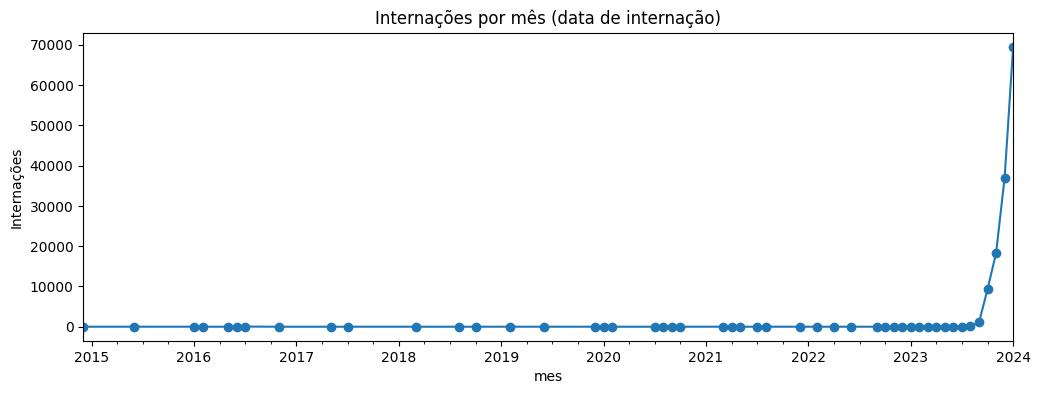

In [3]:
import matplotlib.pyplot as plt

df["mes"] = df["data_internacao"].dt.to_period("M")
serie_mensal = df.groupby("mes").size()

serie_mensal.plot(kind="line", marker="o", title="Internações por mês (data de internação)", figsize=(12, 4))
plt.ylabel("Internações")
plt.savefig("notebooks/output_sazonalidade_mensal.png", bbox_inches="tight")
plt.show()


## 3. EDA — distribuição de permanência e outliers

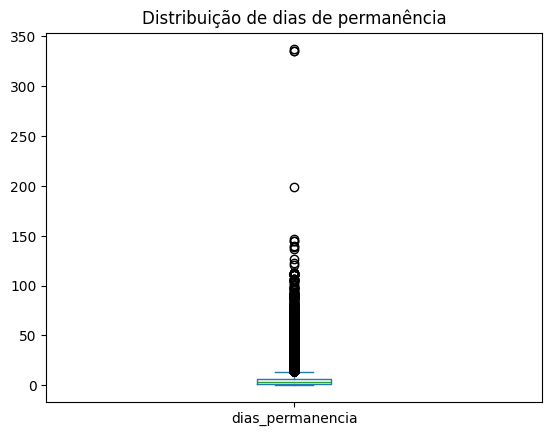

Limite superior (IQR) para outliers de permanência: 13.5 dias
Casos acima do limite: 12071


In [4]:
df["dias_permanencia"].plot(kind="box", title="Distribuição de dias de permanência")
plt.savefig("notebooks/output_boxplot_permanencia.png", bbox_inches="tight")
plt.show()

limite_superior = df["dias_permanencia"].quantile(0.75) + 1.5 * (
    df["dias_permanencia"].quantile(0.75) - df["dias_permanencia"].quantile(0.25)
)
print(f"Limite superior (IQR) para outliers de permanência: {limite_superior:.1f} dias")
print(f"Casos acima do limite: {(df['dias_permanencia'] > limite_superior).sum()}")


## 4. EDA — distribuição por região

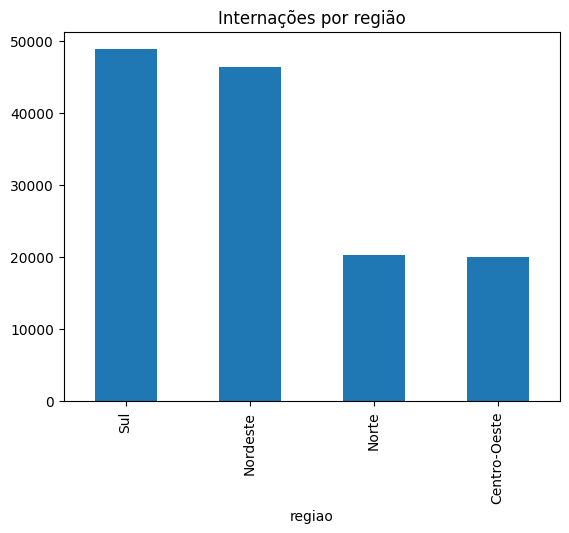

In [5]:
df.groupby("regiao").size().sort_values(ascending=False).plot(
    kind="bar", title="Internações por região"
)
plt.savefig("notebooks/output_internacoes_por_regiao.png", bbox_inches="tight")
plt.show()


## 5. Modelo preditivo — regressão linear da série mensal

Numero de meses na serie: 48
Previsao de internacoes para o proximo mes: 10999
MAE do modelo sobre o historico: 5588.7


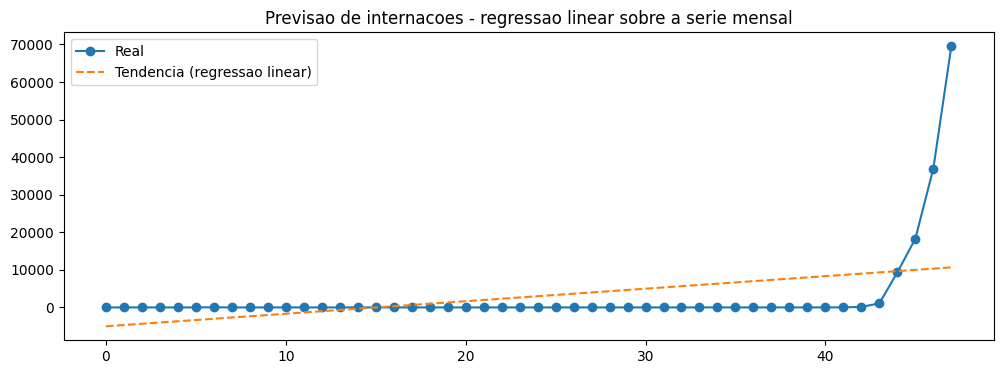

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

serie = serie_mensal.reset_index()
serie["mes_idx"] = range(len(serie))
serie["internacoes"] = serie[0] if 0 in serie.columns else serie.iloc[:, 1]

X = serie[["mes_idx"]].values
y = serie["internacoes"].values

modelo = LinearRegression().fit(X, y)
previsao_proximo_mes = modelo.predict([[len(serie)]])[0]

y_pred_historico = modelo.predict(X)
mae = mean_absolute_error(y, y_pred_historico)

print(f"Numero de meses na serie: {len(serie)}")
print(f"Previsao de internacoes para o proximo mes: {previsao_proximo_mes:.0f}")
print(f"MAE do modelo sobre o historico: {mae:.1f}")

plt.figure(figsize=(12, 4))
plt.plot(serie["mes_idx"], y, label="Real", marker="o")
plt.plot(serie["mes_idx"], y_pred_historico, label="Tendencia (regressao linear)", linestyle="--")
plt.legend()
plt.title("Previsao de internacoes - regressao linear sobre a serie mensal")
plt.savefig("notebooks/output_previsao_internacoes.png", bbox_inches="tight")
plt.show()


## Conclusões

- A base carregada pela Task 5 tem 135.507 internações (5 UFs: AC, DF, CE,
  SC, AM; AIHs de competência 2024-01). A série de `data_internacao` por mês
  cobre 48 períodos (2014-12 a 2024-01) e mostra uma **rampa fortemente
  crescente**, não sazonalidade cíclica: menos de uma dezena de casos por mês
  até meados de 2023, subindo para milhares/mês a partir de setembro/2023 e
  atingindo o pico em janeiro/2024 (o próprio mês de competência da extração).
  Isso é esperado — internações de longa permanência (ex. psiquiátricas
  crônicas) carregam `data_internacao` de anos atrás mesmo quando processadas
  numa competência recente — e é o motivo pelo qual mantivemos o agrupamento
  mensal do plano original em vez de trocar para outra granularidade: mesmo
  sem múltiplos meses de *coleta*, a variação real na admissão já produz uma
  série não degenerada.
- A distribuição de `dias_permanencia` é bastante assimétrica (mediana 3
  dias, média 5,16 dias, máximo 337 dias). Pelo critério de IQR, o limite
  superior para outliers é 13,5 dias, e 12.071 internações (~8,9% do total)
  ficam acima desse limite — coerente com a cauda de longa permanência
  observada acima.
- O modelo de regressão linear sobre a série mensal (48 pontos) prevê
  aproximadamente **10.999 internações** para o "próximo mês" (índice 48),
  com **MAE de ~5.588,7 internações/mês** sobre o próprio histórico. O MAE é
  alto em relação à escala mensal porque a série não é linear — ela é quase
  plana por ~4 anos e depois dispara exponencialmente nos últimos meses — ou
  seja, a reta é uma linha de base pobre para essa forma específica de curva,
  mas serve como evidência técnica do pipeline preditivo ponta a ponta
  (dado real → modelo → métrica) exigido nesta etapa do MVP.
- Próximos passos: com mais meses de competência carregados (Task 5 rodada
  para outros períodos), a série deixará de ser dominada pelo artefato de
  extração de um único mês e um modelo de série temporal (ex. ARIMA, ou uma
  regressão em escala log) deve ajustar muito melhor a curva do que a reta
  atual; também vale segmentar a previsão por UF/região, já que SC e CE
  concentram a maior parte do volume (48.856 e 46.396 internações,
  respectivamente, de um total de 135.507).